In [1]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import gpflow as gpf
import sys
import tensorflow as tf
import numpy as np
sys.path.append("/home/janneke/at-gpflow")
sys.path.append("/home/janneke/changepoint-gp")
from atmodel import AdaptiveTransferSGPR, AdaptiveTransferGPR
from atkernel import TransferKernel
from cpgp.spectral_mixture import SpectralMixture 
import scipy.io
import pandas as pd
from sklearn.model_selection import train_test_split

2025-08-18 16:33:07.136516: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-18 16:33:07.138860: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-18 16:33:07.166637: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-18 16:33:07.166677: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-18 16:33:07.167892: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

### Loading the SARCOS dataset
Dimensions of the SARCOS dataset are 40k samples by 28 features, of which the last 7 torque features are used as sources/targets, much like in the original paper. This is downsampled to 6k samples in order to test the implementation of AT-SGPR. We test this in the univariate setting, using feature 21 as source and feature 22 as target. We standardize the data to improve fitting. Like in the original paper, 5% of the target is used in training the adaptive transfer model.

(6000, 1) (6000, 1)
train 6000 train_target 300
test 6000


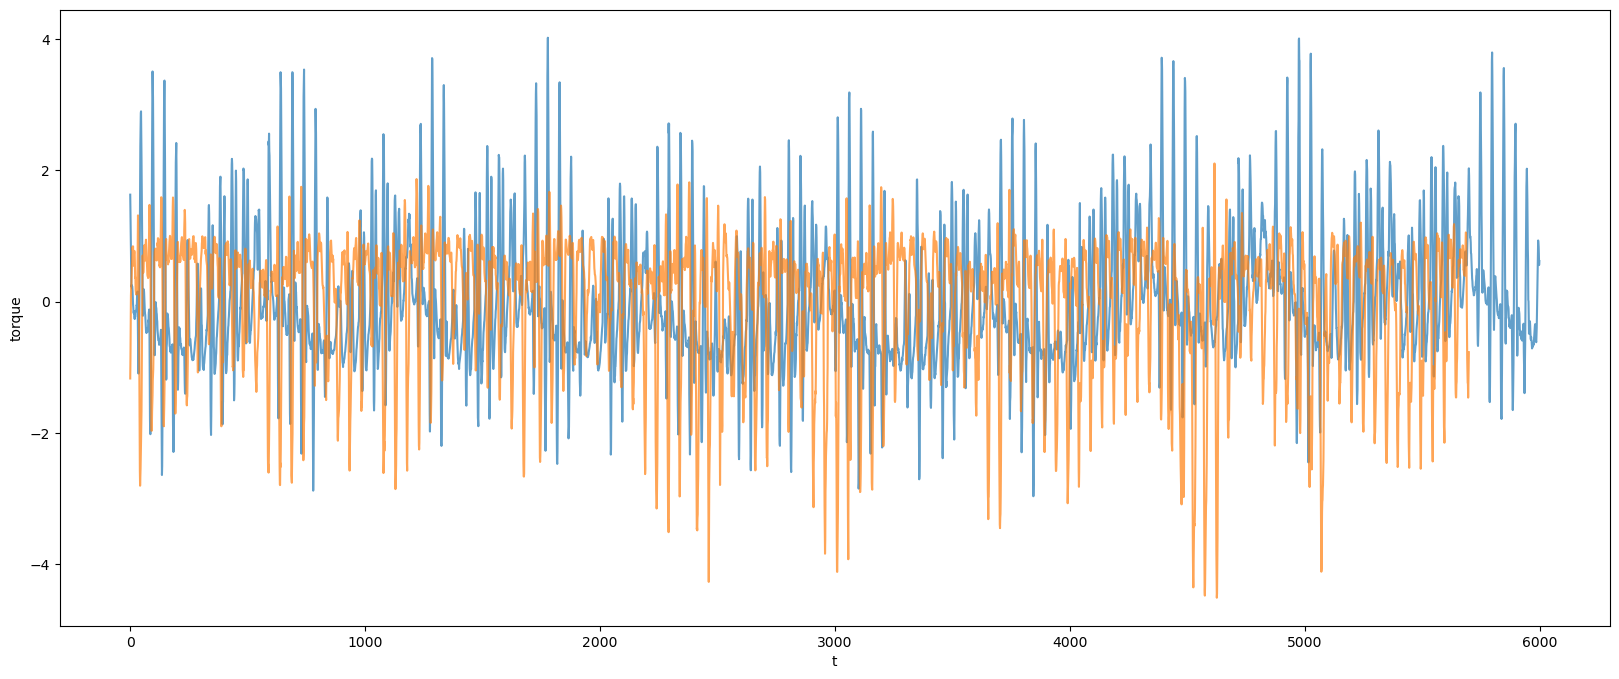

In [2]:
mat = scipy.io.loadmat('sarcos_inv.mat')
sarcos = pd.DataFrame(mat["sarcos_inv"])

Sx = sarcos.loc[:,0].to_numpy()[:6000].reshape(-1, 1)
Sy = sarcos.loc[:,21].to_numpy()[:6000].reshape(-1, 1)

Sx = (Sx - Sx.mean()) / Sx.std()
Sy = (Sy - Sy.mean()) / Sy.std()

Tx = sarcos.loc[:,0].to_numpy()[:6000].reshape(-1, 1)
Ty = sarcos.loc[:,22].to_numpy()[:6000].reshape(-1, 1)


print(Tx.shape, Ty.shape)

from sklearn.model_selection import TimeSeriesSplit

Tx_train, Tx_test, Ty_train, Ty_test = Tx[:300], Tx[300:], Ty[:300], Ty[300:]

Tx_train = (Tx_train - Tx_train.mean()) / Tx_train.std()
Tx_test = (Tx_test - Tx_test.mean()) / Tx_test.std()
Ty_train = (Ty_train - Ty_train.mean()) / Ty_train.std()
Ty_test = (Ty_test - Ty_test.mean()) / Ty_test.std()


print("train", len(Sx), "train_target", len(Tx_train))
print("test", len(Tx))

_, ax = plt.subplots(1, 1, figsize=(20, 8))
ax.plot(Sy, alpha=0.7)
ax.plot(Ty_test, alpha=0.7)
ax.set_xlabel("t")
ax.set_ylabel("torque")
plt.show()

Looking at the data, it seems like the source could possibly provide some information about the target. 

### Fitting the transfer SGPR

Fitting is straightforward. We set the prior for lambda to about 0.4, since we expect the source to be somewhat useful for the target. 

In [4]:
at_gpr = AdaptiveTransferSGPR((Sx, Sy), (Tx_train, Ty_train), gpf.kernels.Periodic(gpf.kernels.RationalQuadratic(20, 5), 100), mu=1, b=0.5, inducing_variable=np.linspace(0, 6000, 300).reshape(-1, 1))
print(at_gpr.get_lmb())
print("Training loss value before training:", at_gpr.training_loss().numpy())
opt = gpf.optimizers.Scipy()
opt.minimize(at_gpr.training_loss, at_gpr.trainable_variables)
gpf.utilities.print_summary(at_gpr)
print(at_gpr.get_lmb())
print("Training loss value after training:", at_gpr.training_loss().numpy())

tf.Tensor(0.41421356237309515, shape=(), dtype=float64)
Training loss value before training: 9434.622307462181
╒═════════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════╕
│ name                                                        │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value               │
╞═════════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════╡
│ AdaptiveTransferSGPR.kernel.mu                              │ Parameter │ Exp              │         │ True        │ ()       │ float64 │ 0.0                 │
├─────────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────┤
│ AdaptiveTransferSGPR.kernel.b                               │ Parameter │ Exp

After fitting, lambda is 1, indicating extreme correlation of the tasks. 

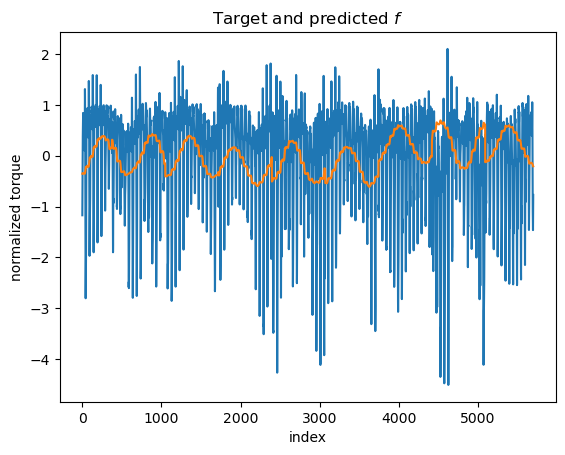

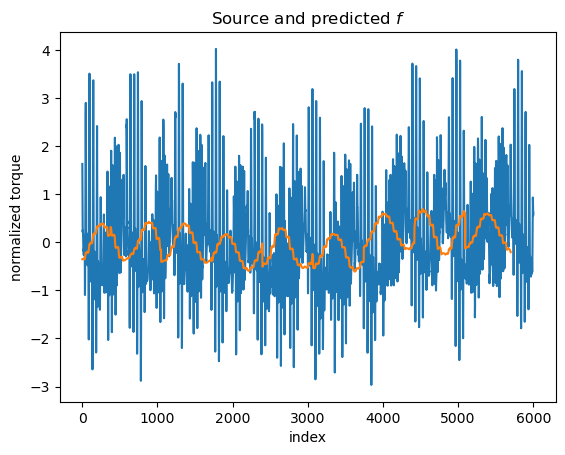

NMSE is 1.1499263304047365
tf.Tensor(1.0, shape=(), dtype=float64)


In [ ]:
fmean, fvar = at_gpr.predict_f(Tx_test)
fmean = fmean - fmean.numpy().mean()

plt.plot(Ty_test)
plt.plot(fmean)
plt.ylabel("normalized torque")
plt.xlabel("index")
plt.title("Target and predicted $f$")

plt.show()


plt.plot(Sy)
plt.plot(fmean)
plt.title("Source and predicted $f$")
plt.ylabel("normalized torque")
plt.xlabel("index")
plt.show()

print("NMSE is", np.mean((Ty_test - fmean) ** 2) / np.var(Ty_test))

In [ ]:
model = gpf.models.SGPR((Tx_train, Ty_train), kernel=gpf.kernels.Periodic(gpf.kernels.RationalQuadratic(20, 5), 100), inducing_variable=np.linspace(0, 6000, 300).reshape(-1, 1))
print("Training loss value before training:", model.training_loss().numpy())
opt = gpf.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables)
gpf.utilities.print_summary(model)
print("Training loss value after training:", model.training_loss().numpy())


Training loss value before training: 426.1896511380199
╒══════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════╕
│ name                                 │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value               │
╞══════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════╡
│ SGPR.kernel.base_kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.44147             │
├──────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────┤
│ SGPR.kernel.base_kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.0779              │
├──────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────

### Comparison to just training on the target

To examine whether negative transfer occurs, fit on just the target (which is obviously faster than on the concatenation of source and target):

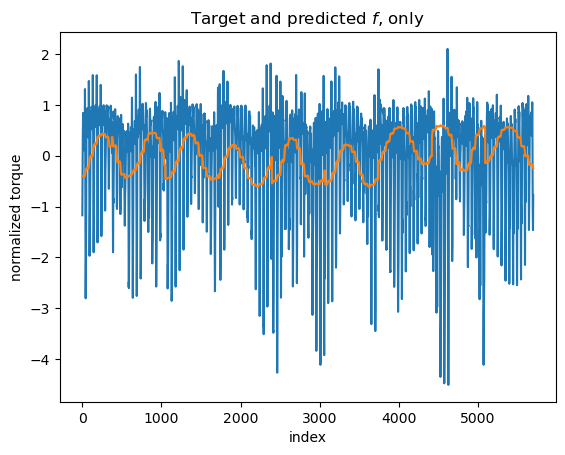

NMSE is 1.1588227689280317


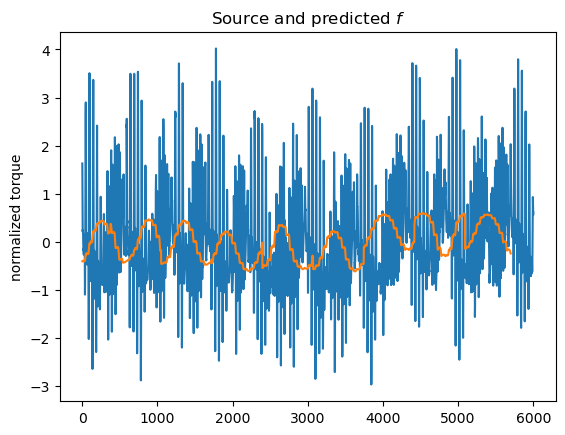

In [ ]:
fmean, fvar = model.predict_f(Tx_test)
fmean = fmean - fmean.numpy().mean()

plt.plot(Ty_test)
plt.plot(fmean)
plt.ylabel("normalized torque")
plt.xlabel("index")
plt.title("Target and predicted $f$, only")

plt.show()


plt.plot(Sy)
plt.plot(fmean)
plt.title("Source and predicted $f$")
plt.ylabel("normalized torque")

print("NMSE is", np.mean((Ty_test - fmean) ** 2) / np.var(Ty_test))

There is apparently some slight difference between the fits, as per the NMSE. 

### Effect of mu/b prior 

You'd expect that "negative transfer" would lead to a worse performance on the task than "transfer all" would. Setting the prior to -0.4 rather than 0.4:

In [5]:
at_gpr = AdaptiveTransferSGPR((Sx, Sy), (Tx_train, Ty_train), gpf.kernels.Periodic(gpf.kernels.RationalQuadratic(20, 5), 100), mu=10, b=0.5, inducing_variable=np.linspace(0, 6000, 300).reshape(-1, 1))
print(at_gpr.get_lmb())
print("Training loss value before training:", at_gpr.training_loss().numpy())
opt = gpf.optimizers.Scipy()
opt.minimize(at_gpr.training_loss, at_gpr.trainable_variables)
gpf.utilities.print_summary(at_gpr)
print(at_gpr.get_lmb())
print("Training loss value after training:", at_gpr.training_loss().numpy())

tf.Tensor(-0.39697731084447274, shape=(), dtype=float64)
Training loss value before training: 9434.627220899662
╒═════════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════╕
│ name                                                        │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value               │
╞═════════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════╡
│ AdaptiveTransferSGPR.kernel.mu                              │ Parameter │ Exp              │         │ True        │ ()       │ float64 │ 13014.72629         │
├─────────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────┤
│ AdaptiveTransferSGPR.kernel.b                               │ Parameter │ Ex

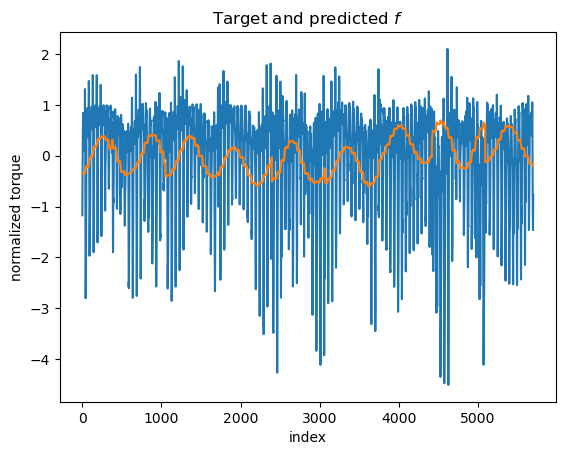

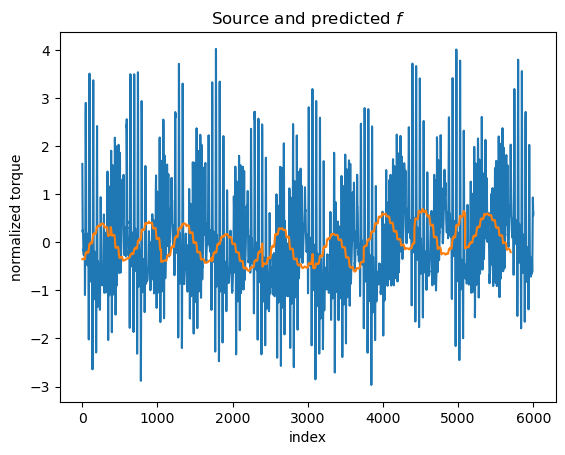

NMSE is 1.1499561611436528


In [6]:
fmean, fvar = at_gpr.predict_f(Tx_test)
fmean = fmean - fmean.numpy().mean()

plt.plot(Ty_test)
plt.plot(fmean)
plt.ylabel("normalized torque")
plt.xlabel("index")
plt.title("Target and predicted $f$")

plt.show()


plt.plot(Sy)
plt.plot(fmean)
plt.title("Source and predicted $f$")
plt.ylabel("normalized torque")
plt.xlabel("index")
plt.show()

print("NMSE is", np.mean((Ty_test - fmean) ** 2) / np.var(Ty_test))

This gives us an NMSE that is similar up to three decimals to the one above (on this run at least).